In [ ]:
!pip install xgboost joblib

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [31]:
from google.colab import files

uploaded = files.upload()

Saving hdfc_loan_dataset_cleaned.csv to hdfc_loan_dataset_cleaned.csv


In [33]:
df = pd.read_csv(
    "hdfc_loan_dataset_cleaned.csv"
)

df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0.0,0.0,31.0,1.0,0.0,2.0,0.0,1.0,56976.0,0.0,...,11.74700,2.0,2.0,0.0,5.0,857743.0,6.940000e+11,9.068672e+09,31.0,8.0
1,1.0,0.0,31.0,1.0,0.0,0.0,0.0,3.0,1856.0,0.0,...,19.84825,0.0,2.0,5.0,15.0,863836.0,6.330000e+11,9.990773e+09,31.0,2.0
2,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,64553.0,0.0,...,3.08200,2.0,2.0,4.0,19.0,834796.0,1.660000e+11,9.195085e+09,1.0,12.0
3,3.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,88450.0,0.0,...,0.62100,0.0,2.0,1.0,27.0,438590.0,5.528183e+10,9.179336e+09,4.0,11.0
4,4.0,0.0,11.0,1.0,1.0,3.0,0.0,2.0,9539.0,0.0,...,1.73600,1.0,2.0,9.0,12.0,495224.0,1.560000e+11,9.795137e+09,11.0,14.0


In [35]:
df.columns.tolist()

['Loan_ID',
 'Bank',
 'Customer_Name',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Employment_Status',
 'Applicant_Income',
 'Coapplicant_Income',
 'Loan_Amount',
 'Loan_Term_Months',
 'Credit_History',
 'Property_Area',
 'Age',
 'Loan_Status',
 'CIBIL_Score',
 'Annual_Household_Income',
 'Debt_to_Income_Ratio',
 'Purpose_of_Loan',
 'Existing_EMIs',
 'Number_of_Previous_Loans',
 'Default_History_Count',
 'Employment_Length_Years',
 'Business_Type',
 'Asset_Value',
 'Guarantor',
 'Co-signer_Relationship',
 'Monthly_Expense',
 'Organization_Type',
 'Region_Branch',
 'Mobile_Verified',
 'Email_Verified',
 'Institutional_Relationships',
 'Application_Text',
 'Customer_Feedback',
 'Agent_Notes',
 'Loan_to_Annual_Income',
 'Customer_Sentiment',
 'Religion',
 'State',
 'City',
 'PIN_Code',
 'Aadhaar_Synthetic',
 'Phone_Number',
 'Email',
 'Occupation']

In [37]:
import os

os.makedirs(
    "visuals/usecase1",
    exist_ok=True
)

In [38]:
features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Employment_Status",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",
    "Education",
    "Property_Area"
]

X = df[features]

y = df["Loan_Status"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(800, 10)
(200, 10)


In [40]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    print(f"\n{model_name}")

    print(
        "Accuracy:",
        round(
            accuracy_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "F1 Score:",
        round(
            f1_score(
                y_true,
                y_pred
            ),
            4
        )
    )

    print(
        "\nClassification Report:\n"
    )

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [41]:
lr_model = LogisticRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(
    X_test
)

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_predictions
)


Logistic Regression
Accuracy: 0.83
Precision: 0.7612
Recall: 0.7391
F1 Score: 0.75

Classification Report:

              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       131
         1.0       0.76      0.74      0.75        69

    accuracy                           0.83       200
   macro avg       0.81      0.81      0.81       200
weighted avg       0.83      0.83      0.83       200



In [43]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_predictions = dt_model.predict(
    X_test
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_predictions
)


Decision Tree
Accuracy: 0.785
Precision: 0.7031
Recall: 0.6522
F1 Score: 0.6767

Classification Report:

              precision    recall  f1-score   support

         0.0       0.82      0.85      0.84       131
         1.0       0.70      0.65      0.68        69

    accuracy                           0.79       200
   macro avg       0.76      0.75      0.76       200
weighted avg       0.78      0.79      0.78       200



In [44]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)


Random Forest
Accuracy: 0.835
Precision: 0.7903
Recall: 0.7101
F1 Score: 0.7481

Classification Report:

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88       131
         1.0       0.79      0.71      0.75        69

    accuracy                           0.83       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.83      0.83      0.83       200



In [45]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions
)


XGBoost
Accuracy: 0.84
Precision: 0.7606
Recall: 0.7826
F1 Score: 0.7714

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.87      0.88       131
         1.0       0.76      0.78      0.77        69

    accuracy                           0.84       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.84      0.84      0.84       200



In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, dt_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,XGBoost,0.840
2,Random Forest,0.835
0,Logistic Regression,0.830
1,Decision Tree,0.785


In [53]:
params = {
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 5, 7],
    "n_estimators": [100, 200],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

Best Accuracy:
0.8837499999999998


In [54]:
best_xgb = grid_search.best_estimator_

best_predictions = best_xgb.predict(
    X_test
)

evaluate_model(
    "Tuned XGBoost",
    y_test,
    best_predictions
)


Tuned XGBoost
Accuracy: 0.83
Precision: 0.7465
Recall: 0.7681
F1 Score: 0.7571

Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.86      0.87       131
         1.0       0.75      0.77      0.76        69

    accuracy                           0.83       200
   macro avg       0.81      0.82      0.81       200
weighted avg       0.83      0.83      0.83       200



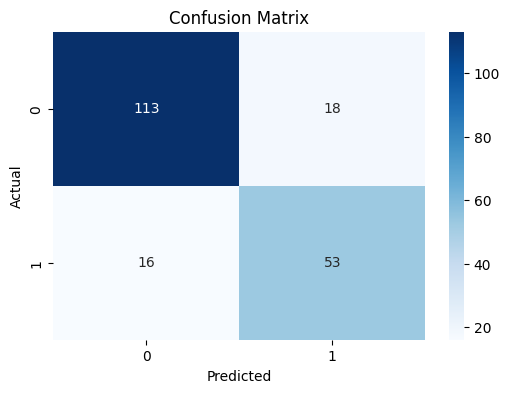

In [55]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "visuals/usecase1/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [56]:
probabilities = best_xgb.predict_proba(
    X_test
)[:,1]

roc_score = roc_auc_score(
    y_test,
    probabilities
)

print(
    "ROC-AUC Score:",
    roc_score
)

ROC-AUC Score: 0.8988826197588229


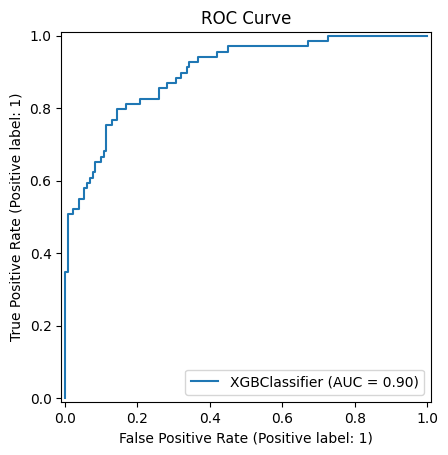

In [57]:
RocCurveDisplay.from_estimator(
    best_xgb,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.savefig(
    "visuals/usecase1/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

In [58]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
7,Debt_to_Income_Ratio,0.383792
3,Credit_History,0.230274
2,Loan_Amount,0.089890
4,CIBIL_Score,0.067152
0,Applicant_Income,0.062874
1,Coapplicant_Income,0.042901
8,Education,0.039806
5,Employment_Status,0.036831
6,Existing_EMIs,0.026933
9,Property_Area,0.019547


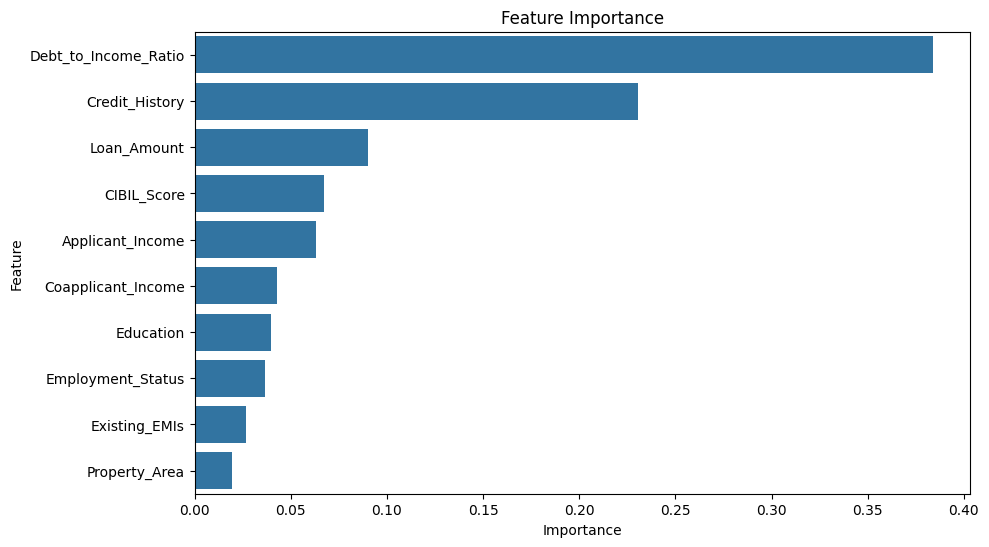

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "visuals/usecase1/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [60]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

In [61]:
joblib.dump(
    best_xgb,
    "models/loan_approval_model.pkl"
)

['models/loan_approval_model.pkl']

In [62]:
import shutil

shutil.make_archive(
    "usecase1_outputs",
    "zip",
    "."
)

'/content/usecase1_outputs.zip'

In [63]:
from google.colab import files

files.download(
    "usecase1_outputs.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>